# From an observed spectrum to stellar parameters

Given a flux-calibrated (or continuum-normalized) spectrum of a single star, infer
Teff, log g, [Fe/H], radial velocity, and a flux amplitude — with **full posteriors
and the Bayesian evidence** — using tengri-stars.

The forward model is a pre-computed synthetic grid interpolated with tengri's
node-exact monotone-cubic (PCHIP) kernel; the sampler is tengri's Nested Slice
Sampler (NSS). NSS samples in bounded physical space and needs **no gradients**,
so grid-edge clamping and the classic stellar degeneracies (Teff–[Fe/H],
dwarf/giant bimodality) are handled natively, and log Z comes for free.

**The grid below is a physically-motivated toy** — Hβ carries Teff, the Mg b
triplet carries log g, an Fe I line comb carries [Fe/H] — standing in for the
Turbospectrum LTE (TSLTE) grids until those are wired in. Swap `build_toy_grid()`
for `SpectralGrid.from_arrays(...)` on real grid spectra and everything downstream
is unchanged.

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter

import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tengri import Uniform

from tengri_stars import (
    SpectralGrid,
    StarModel,
    fit_nss,
    overlay_corner,
)

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(3)

## 1. A toy synthetic spectral grid

Continuum-normalized spectra on a (Teff, log g, [Fe/H]) grid, 4500–5500 Å.
Line depths follow a saturating curve of growth in metallicity so the
[Fe/H] response is realistically nonlinear.

In [2]:
WAVE = np.arange(4500.0, 5500.0, 0.5)  # rest-frame vacuum [Å]

HBETA = 4862.68
MGB = (5167.32, 5172.68, 5183.60)  # gravity-sensitive triplet
FE_LINES = np.linspace(4900.0, 5450.0, 12)  # toy Fe I comb


def toy_spectrum(teff, logg, feh):
    """Continuum-normalized toy spectrum at one grid point."""
    flux = np.ones_like(WAVE)
    # Hβ: strengthens with Teff (toward the Balmer maximum), pressure-broadened.
    d_hb = 0.15 + 0.30 * (teff - 4000.0) / 1500.0
    w_hb = 2.5 + 0.4 * logg
    flux -= d_hb * np.exp(-0.5 * ((WAVE - HBETA) / w_hb) ** 2)
    # Mg b: deepens with gravity and metallicity.
    d_mg = (0.10 + 0.06 * logg) * (1.0 - np.exp(-(10.0 ** (feh + 1.5))))
    for line in MGB:
        flux -= d_mg * np.exp(-0.5 * ((WAVE - line) / 0.8) ** 2)
    # Fe I comb: metallicity carrier with curve-of-growth saturation.
    d_fe = 0.55 * (1.0 - np.exp(-(10.0 ** (feh + 1.0)))) * (4750.0 / teff)
    for line in FE_LINES:
        flux -= d_fe * np.exp(-0.5 * ((WAVE - line) / 0.6) ** 2)
    return np.clip(flux, 0.02, None)


def build_toy_grid():
    teff_nodes = np.linspace(4000.0, 5500.0, 7)
    logg_nodes = np.linspace(0.5, 4.5, 5)
    feh_nodes = np.linspace(-3.5, 0.0, 8)
    flux = np.empty((7, 5, 8, WAVE.size))
    for i, t in enumerate(teff_nodes):
        for j, g in enumerate(logg_nodes):
            for k, z in enumerate(feh_nodes):
                flux[i, j, k] = toy_spectrum(t, g, z)
    return SpectralGrid.from_arrays(
        teff=teff_nodes, logg=logg_nodes, feh=feh_nodes, wave=WAVE, flux=flux
    )


grid = build_toy_grid()
model = StarModel(spectral_grid=grid)  # spectra default to PCHIP interpolation

## 2. A mock observed star

A metal-poor giant at +45 km/s, observed at R = 2500 and S/N ≈ 30 per pixel.

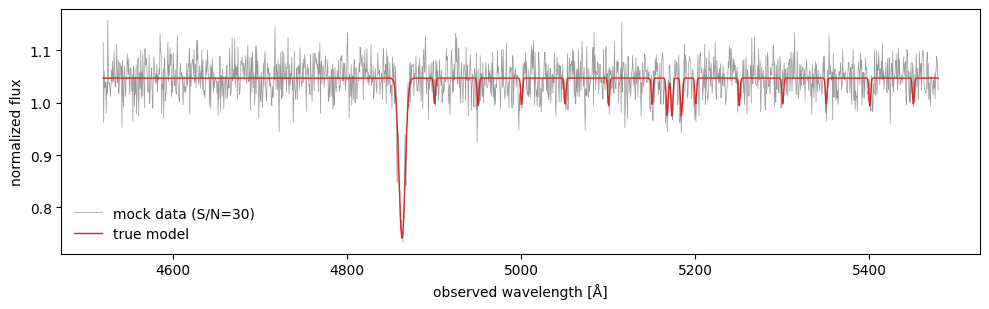

In [3]:
TRUTH = {"teff": 4750.0, "logg": 2.4, "feh": -1.8, "rv_kms": 45.0, "log_amp": 0.02}
RESOLUTION = 2500.0
SNR = 30.0

wave_obs = jnp.asarray(np.arange(4520.0, 5480.0, 0.6))
flux_true = model.predict_spectrum(wave_obs=wave_obs, resolution=RESOLUTION, **TRUTH)
flux_err = np.full(wave_obs.shape, 1.0 / SNR)
flux_obs = jnp.asarray(np.asarray(flux_true) + rng.normal(0.0, flux_err))

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(wave_obs, flux_obs, lw=0.5, color="0.6", label=f"mock data (S/N={SNR:.0f})")
ax.plot(wave_obs, flux_true, lw=1.0, color="C3", label="true model")
ax.set(xlabel="observed wavelength [Å]", ylabel="normalized flux")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Fit: full posterior with tengri's nested slice sampler

Five free parameters. Priors are tengri `Uniform` distributions; the likelihood
is a plain per-pixel Gaussian. `fit_nss` returns equal-weight posterior samples,
log Z, and the effective sample size.

In [4]:
priors = {
    "teff": Uniform(4000.0, 5500.0),
    "logg": Uniform(0.5, 4.5),
    "feh": Uniform(-3.5, 0.0),
    "rv_kms": Uniform(-300.0, 300.0),
    "log_amp": Uniform(-0.2, 0.2),
}


def loglikelihood(p):
    pred = model.predict_spectrum(
        wave_obs=wave_obs,
        teff=p["teff"],
        logg=p["logg"],
        feh=p["feh"],
        rv_kms=p["rv_kms"],
        log_amp=p["log_amp"],
        resolution=RESOLUTION,
    )
    return -0.5 * jnp.sum(((pred - flux_obs) / flux_err) ** 2)


t0 = time.time()
result = fit_nss(loglikelihood, priors, key=jax.random.PRNGKey(7), n_live=400, num_delete=40)
print(f"total wall time (incl. JIT compile): {time.time() - t0:.1f} s")
print(
    f"NSS iterations: {result.n_iterations},  log Z = {result.logz:.1f},  ESS = {result.ess:.0f}"
)

total wall time (incl. JIT compile): 43.8 s
NSS iterations: 186,  log Z = -775.3,  ESS = 2200


## 4. Posteriors

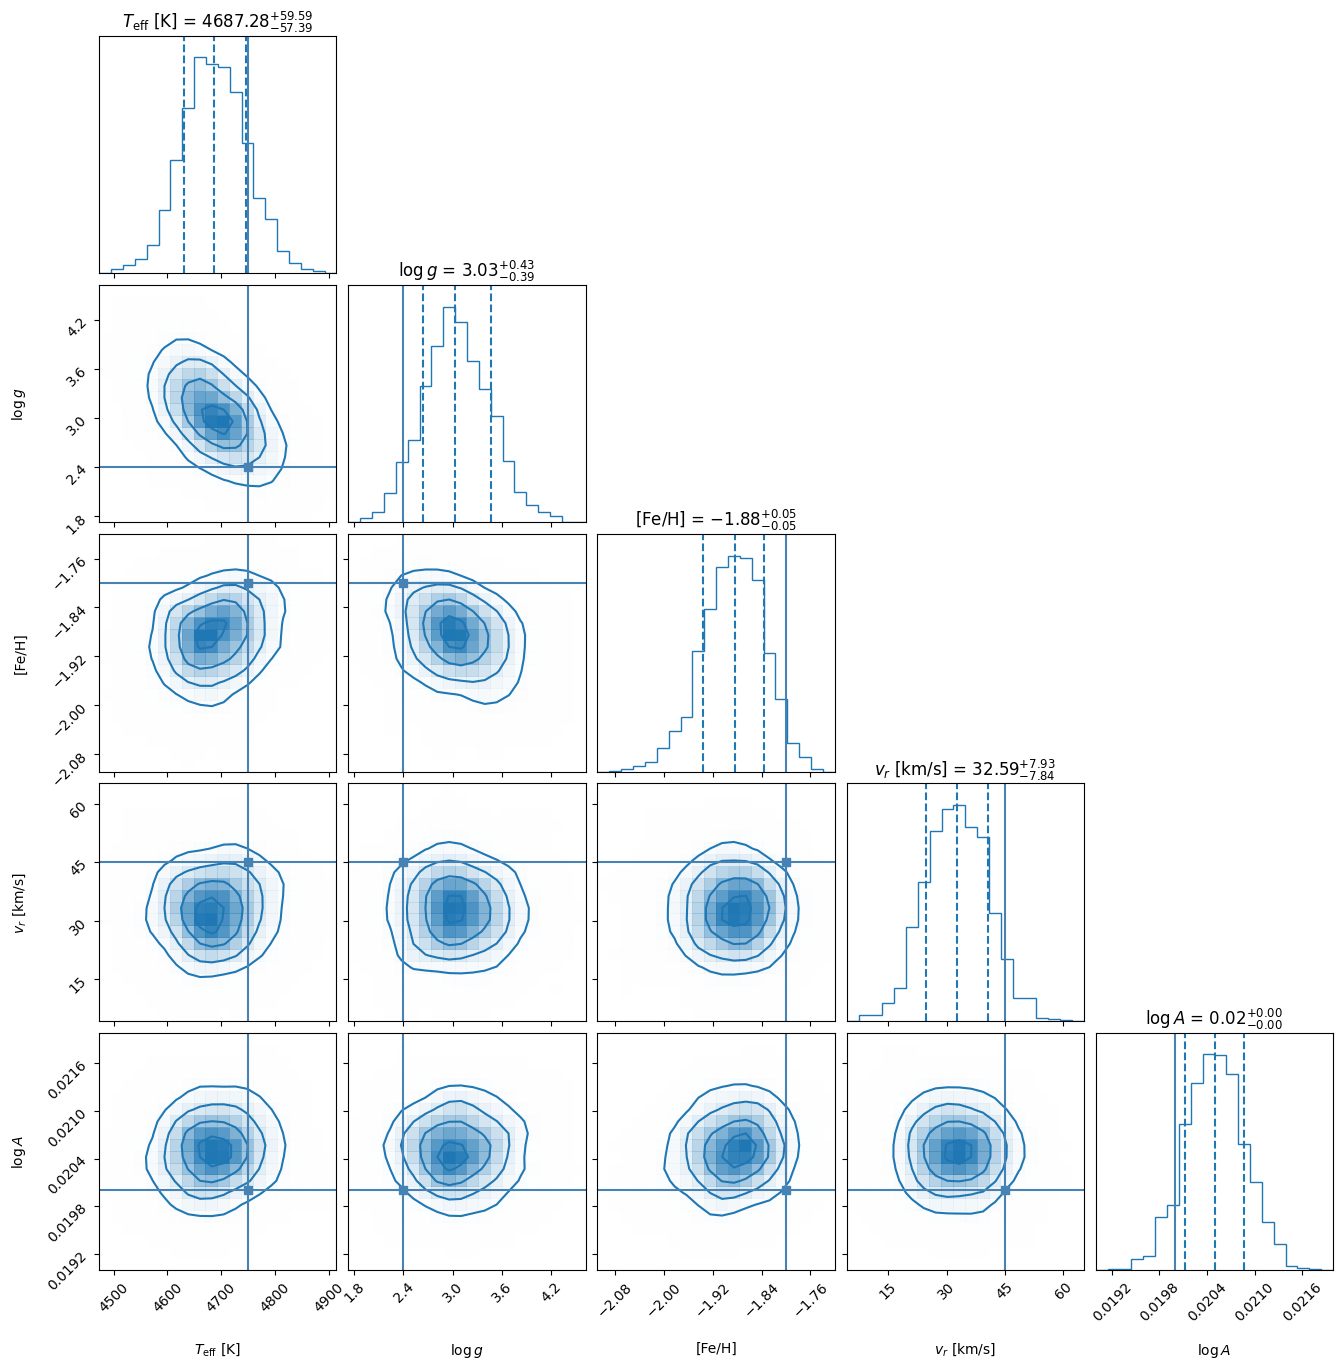

teff    :   4687.28  68% [  4629.88,   4746.87]   truth   4750.00
logg    :      3.03  68% [     2.64,      3.47]   truth      2.40
feh     :     -1.88  68% [    -1.94,     -1.84]   truth     -1.80
rv_kms  :     32.59  68% [    24.76,     40.52]   truth     45.00
log_amp :      0.02  68% [     0.02,      0.02]   truth      0.02


In [5]:
labels = [r"$T_{\rm eff}$ [K]", r"$\log g$", "[Fe/H]", r"$v_r$ [km/s]", r"$\log A$"]
names = list(priors)
fig = overlay_corner(
    [result.samples],
    names=names,
    labels=labels,
    truths=TRUTH,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".2f",
)
plt.show()

med, ci = result.median(), result.interval(0.68)
for n in names:
    print(f"{n:8s}: {med[n]:9.2f}  68% [{ci[n][0]:9.2f}, {ci[n][1]:9.2f}]   truth {TRUTH[n]:9.2f}")

## 5. Joint spectrum + photometry

The MAGIC trick, end to end: **pre-integrate the same spectral grid through
filters once**, then fit-time photometry is a lookup — no wavelength integral in
the sampler. Two toy box filters stand in for survey bandpasses; with real grids
this is tengri's filter-integration pipeline over LSST/DES/CaHK curves.

In [6]:
from tengri.utils import edges_for_grid

from tengri_stars import PhotometryGrid

BANDS = {"b_box": (4600.0, 4900.0), "v_box": (5000.0, 5300.0)}
phot = np.stack(
    [
        -2.5 * np.log10(np.asarray(grid.flux[..., (lo <= WAVE) & (hi >= WAVE)]).mean(axis=-1))
        for lo, hi in BANDS.values()
    ],
    axis=-1,
)
phot_grid = PhotometryGrid(
    axes=grid.axes,
    edges=tuple(edges_for_grid(a) for a in grid.axes),
    phot=jnp.asarray(phot),
    filter_names=tuple(BANDS),
    coverage=jnp.ones(phot.shape[:3], bool),
)
joint_model = StarModel(grid=phot_grid, spectral_grid=grid, interp_method="pchip")

mu_true, sig_mag = 14.2, 0.02
mags_obs = joint_model.predict_mags(
    teff=TRUTH["teff"], logg=TRUTH["logg"], feh=TRUTH["feh"], mu=mu_true
) + jnp.asarray(rng.normal(0.0, sig_mag, 2))

joint_priors = dict(priors, mu=Uniform(10.0, 20.0))


def joint_loglikelihood(p):
    log_l_spec = loglikelihood(p)
    pred_mags = joint_model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"], mu=p["mu"])
    return log_l_spec + (-0.5 * jnp.sum(((pred_mags - mags_obs) / sig_mag) ** 2))


t0 = time.time()
joint = fit_nss(
    joint_loglikelihood, joint_priors, key=jax.random.PRNGKey(11), n_live=400, num_delete=40
)
print(
    f"joint fit wall time: {time.time() - t0:.1f} s,  "
    f"log Z = {joint.logz:.1f}, ESS = {joint.ess:.0f}"
)
jm, jci = joint.median(), joint.interval(0.68)
print(
    f"mu       : {jm['mu']:9.2f}  "
    f"68% [{jci['mu'][0]:9.2f}, {jci['mu'][1]:9.2f}]   truth {mu_true:9.2f}"
)

joint fit wall time: 67.3 s,  log Z = -781.7, ESS = 2380
mu       :     14.18  68% [    14.17,     14.19]   truth     14.20


## 6. The same fit with NUTS (blackjax)

`fit_nuts` runs blackjax NUTS on the information Hamiltonian in unbounded
ξ-space (each prior's `unstandardize` maps standard-normal ξ into its bounded
support — mandatory for grid models, whose lookup gradient is zero outside the
hull). Gradients through the PCHIP interpolant are C¹, which NUTS handles fine;
switch `interp_method='triweight'` for C² if adaptation ever struggles.

In [7]:
from tengri_stars import fit_nuts

t0 = time.time()
nuts = fit_nuts(loglikelihood, priors, key=jax.random.PRNGKey(5), num_warmup=800, num_samples=1500)
print(
    f"NUTS wall time: {time.time() - t0:.1f} s  "
    f"(acceptance {nuts.acceptance_rate:.2f}, {nuts.num_divergent} divergences)"
)
nm, nci = nuts.median(), nuts.interval(0.68)
print(f"{'':10s}{'NSS median':>12s}{'NUTS median':>12s}{'truth':>10s}")
for n in names:
    print(f"{n:10s}{med[n]:12.2f}{nm[n]:12.2f}{TRUTH[n]:10.2f}")

# Wall time alone is misleading: what matters is *independent* samples per
# second. NUTS chains are autocorrelated; nested-sampling draws are not.
print(f"\nNSS : {result.wall_time:5.1f} s, ESS {result.ess:6.0f}  → {result.ess_rate:6.0f} ESS/s")
print(f"NUTS: {nuts.wall_time:5.1f} s, ESS {nuts.min_ess:6.0f}  → {nuts.ess_rate:6.0f} ESS/s")
print(f"  NUTS ESS per parameter: { ({n: round(v) for n, v in nuts.ess.items()}) }")

NUTS wall time: 26.6 s  (acceptance 0.91, 0 divergences)
            NSS median NUTS median     truth
teff           4687.28     4684.63   4750.00
logg              3.03        3.07      2.40
feh              -1.88       -1.88     -1.80
rv_kms           32.59       32.57     45.00
log_amp           0.02        0.02      0.02

NSS :  42.4 s, ESS   2200  →     52 ESS/s
NUTS:   3.2 s, ESS    858  →    271 ESS/s
  NUTS ESS per parameter: {'teff': 1027, 'logg': 1023, 'feh': 858, 'rv_kms': 1427, 'log_amp': 1500}


### Posterior overlay — do two very different samplers agree?

NSS (no gradients, physical space, evidence for free) and NUTS (gradients,
unbounded ξ-space) attack the same posterior from opposite ends. Contour
agreement is a strong end-to-end check of both the forward model and the
samplers.

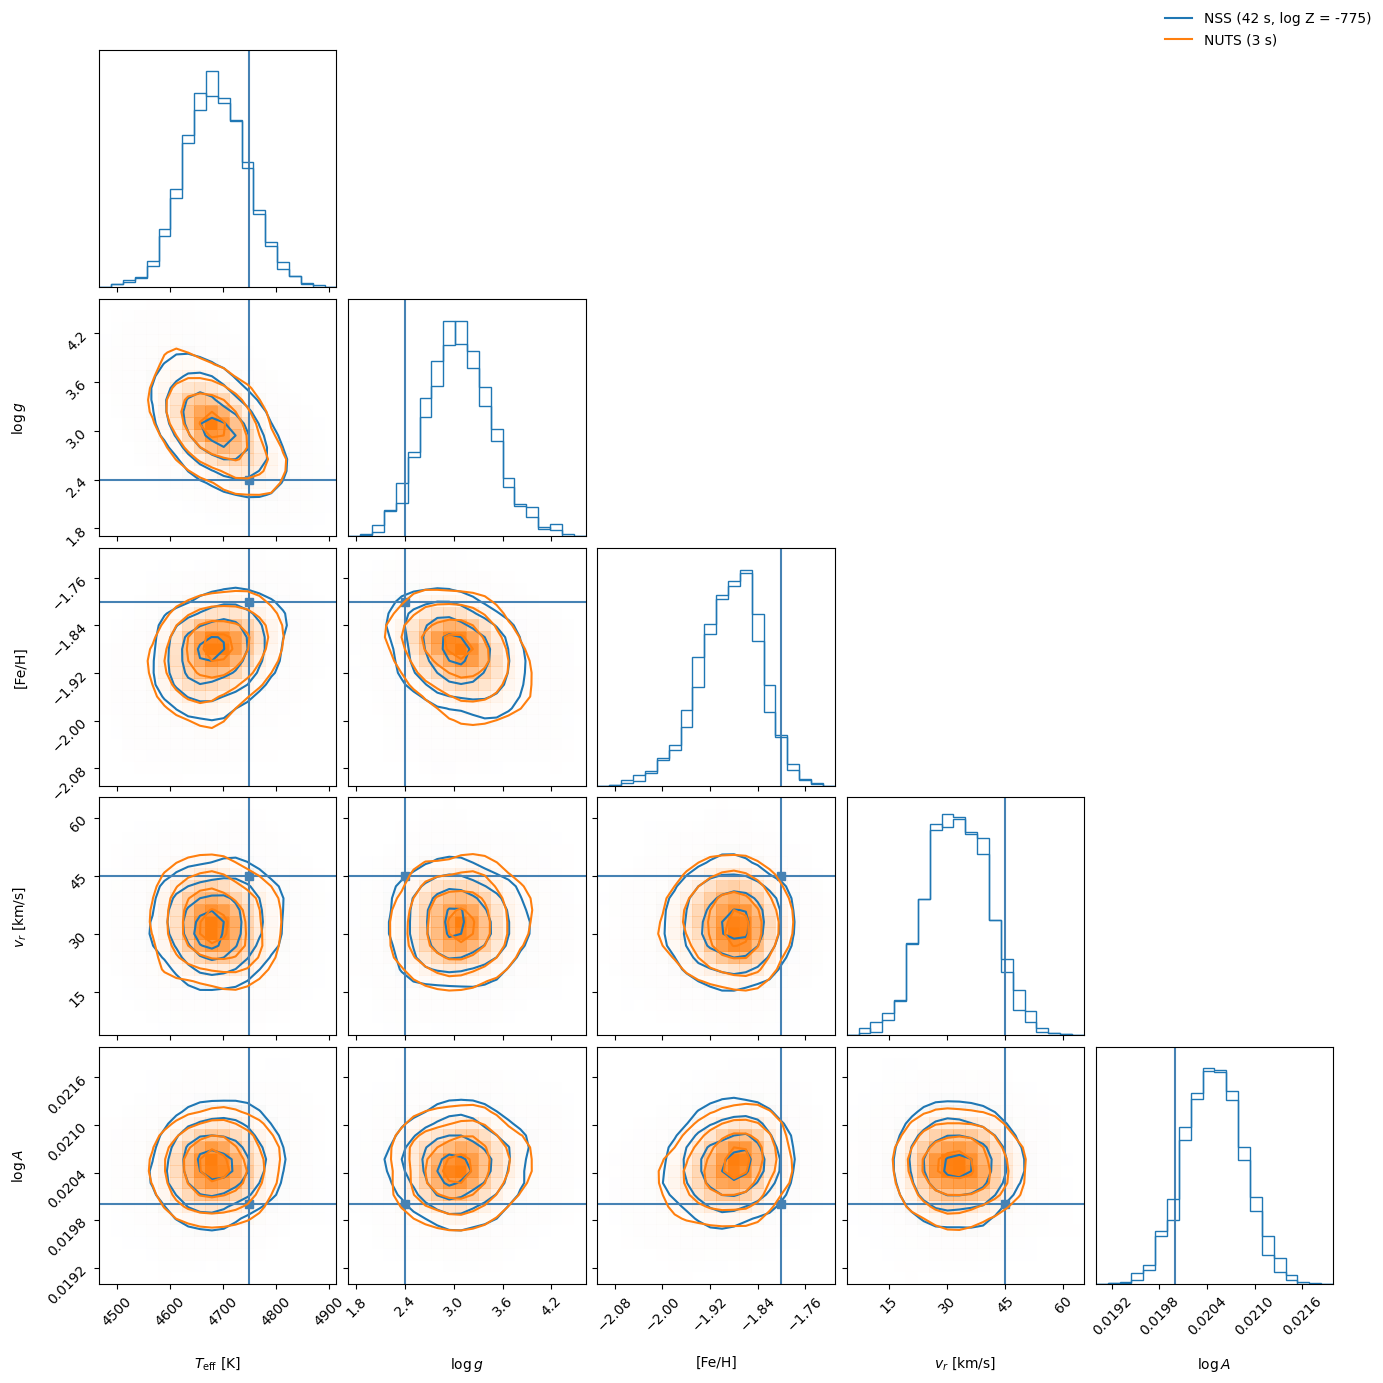

In [8]:
fig = overlay_corner(
    [result.samples, nuts.samples],
    names=names,
    labels=labels,
    colors=["C0", "C1"],
    legend_labels=[
        f"NSS ({result.wall_time:.0f} s, log Z = {result.logz:.0f})",
        f"NUTS ({nuts.wall_time:.0f} s)",
    ],
    truths=TRUTH,
)
plt.show()

## Notes

- **Why NSS as the default**: stellar-parameter posteriors are degenerate and
  often multimodal (Teff–[Fe/H] line-blanketing trade-off, dwarf/giant branch
  splits when photometry is weak). Nested sampling maps multimodal posteriors
  without tuning, needs no gradients — so the PCHIP node-exact interpolant is
  strictly preferable here — and its log Z lets you *compare models*
  (e.g. dwarf vs giant prior classes, one grid family vs another).
- **When NUTS instead**: high-dimensional joint fits (many nuisance calibration
  coefficients) where the posterior is unimodal; then the triweight kernel's C²
  gradients matter and tengri's NUTS backend applies. Wiring StarModel into
  tengri's `Fitter` (for `run("nuts")`, `run("nss")`, …) is pending a small
  upstream extensibility seam in tengri `Parameters`.
- **Real grids**: replace `build_toy_grid()` with TSLTE spectra
  (`SpectralGrid.from_arrays`) and the pre-integrated photometry FITS
  (`load_photometry_grid("TSLTE_combined_photometry.fits")`). Everything else —
  RV, LSF, priors, sampler, corner — is unchanged.